In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [3]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimisers import *


In [4]:
from elements import install_septa
#lineSRX = xt.lineSRX.from_json("../database/lhc_q22.json")
lineSRX = xt.Line.from_json("../database/sps_for_sx.json")


# REFERENCE PARTICLE
lineSRX.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
lineSRX.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=lineSRX.get_table()['s', 'zs.21633']+1e-3)
lineSRX.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
lineSRX.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
lineSRX.insert_element("TECA.exit", xt.Marker(), at_s = 4020.8939 + TECS.length)
lineSRX.insert_element(name="teca", element=xt.Marker(), at_s=4022)

#lineSRX.insert_element("TECS.everest_crystal", TECS, at_s = lineSRX.get_table()['s', 'tecs.21602'] )

lineSRX.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = lineSRX.get_table()['s', 'TECA.entry']

#lineSRX.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4492 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4492 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4495 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4497 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4499 [00:00<?, ?it/s]

In [5]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = lineSRX.get_table()['s', 'TECA.entry']
tpst_position = lineSRX.get_table()['s', 'tpst.21760']
tcsm_position = lineSRX.get_table()['s', 'tcsm.51932.']

# Knobs for Slow Resonant Extraction

In [6]:
# Define constants for the simulation
N_EX = 10e-6  # Normalized emittance in the x direction
N_EY = 5e-6  # Normalized emittance in the y direction
DPP = 1e-4  # Momentum spread

# Set the septum aperture size
septum_aperture_size = 68e-3  # Size of the septum aperture in meters

# Define slicing strategies for thick elements, if needed
Strategy = xt.slicing.Strategy
Teapot = xt.slicing.Teapot

# Define a rectangular limit for the septum aperture
septum = xt.LimitRect(min_x=-1., max_x=septum_aperture_size,
                      min_y=-1., max_y=1.)  # Rectangle defined by min/max values

lineSRX.discard_tracker()
# Insert the defined septum element into the lineSRX at a specified index
lineSRX.insert_element(name="zs_aperture", element=septum, index='zs.21633')
#lineSRX.cycle("zs_aperture", inplace=True)  # Cycle the lineSRX to ensure proper setup
lineSRX.build_tracker()  # Build the tracker for the simulation

In [7]:
import optimisers as op
import importlib
importlib.reload(op)

px_target = 1e-4
#x_target = 0.0394 * 1.90  # This is the position of the TPST blade times a factor, THIS VALUE IS GOOD FOR THE ORIGINAL POSITION OF THE SEPTUM
x_target = 0.0394 * 1.2

"""
# Adjust the horizontal bump for the extraction
adjustBumpLSS2SRX = op.horizontal_bumpLSS2(lineSRX, x_target * 0.5, px_target)

adjustBumpLSS2SRX.log()

adjustBumpLSS2SRX.step(10)
adjustBumpLSS2SRX.target_status()
adjustBumpLSS2SRX.vary_status()
knobs_after_matchLSS2SRX = adjustBumpLSS2SRX.get_knob_values()
knobs_before_matchLSS2SRX = adjustBumpLSS2SRX.get_knob_values(iteration=0)
"""

# Adjust the horizontal bump for the TECA
adjustBumpLSS4SRX = op.horizontal_bumpLSS4(lineSRX)

adjustBumpLSS4SRX.log()

adjustBumpLSS4SRX.step(10)
adjustBumpLSS4SRX.target_status()
adjustBumpLSS4SRX.vary_status()
knobs_after_matchLSS4SRX = adjustBumpLSS4SRX.get_knob_values()
knobs_before_matchLSS4SRX = adjustBumpLSS4SRX.get_knob_values(iteration=0)


                                             
Optimize - start penalty: 0.3721        
Matching: model call n. 19               
Optimize - end penalty:  5.50718e-15
                                             
Optimize - start penalty: 5.507e-15      
Matching: model call n. 22               
Optimize - end penalty:  5.50718e-15
Target status:                           
id state tag           tol_met       residue   current_val    target_val description                                 
0  ON    START_x          True             0             0             0 ('x', 'mpsh.41402'), val=0, tol=1e-09, w ...
1  ON    START_px         True             0             0             0 ('px', 'mpsh.41402'), val=0, tol=1e-09,  ...
2  ON    TECA.entry_x     True  -2.42861e-16      -0.03374      -0.03374 ('x', 'TECA.entry'), val=-0.03374, tol=1 ...
3  ON    TECA.entry_px    True  -3.90313e-18      -0.00157      -0.00157 ('px', 'TECA.entry'), val=-0.00157, tol= ...
4  ON    END_x            True  -4.

In [8]:
# Switch on extraction bump
#lineSRX.vv["extr_bump_knob"] = 0.88
lineSRX.vv["extr_bump_knob"] = 0.88
 
# Extraction tunes
opt = lineSRX.match(solve=False, method = '4d',
    vary=[
        xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
    ],
    targets=[
        xt.TargetSet(qx=26.666666666, qy=26.58, tol=1e-5),    # Desired target tunes
        xt.TargetSet(dqx=-1 * 26., dqy=0.47 * 26., tol=1e-3),    # Desired dispersion values
    ])

opt.solve()  # Solve the matching problem to find optimal parameters

# Switch on extraction sextupoles
lineSRX.vv["sps_on_extraction"] = 1.0
# Switch on extraction bump
#lineSRX.vv["extr_bump_knob"] = 0.88

opt.log()

# Specify number of particles for the simulation
n_part = 100

# Generate normalized 2D Gaussian distributions for particle coordinates and momenta
x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)

# Initialize longitudinal coordinate and momentum spread
zeta = 0.0
dpp = np.random.rand(n_part) * DPP

                                             
Optimize - start penalty: 28.32         
Matching: model call n. 13               
Optimize - end penalty:  4.43228e-05


In [9]:
lineSRX.vv["extr_bump_knob"]

0.88

## Knobs dataframe SRX

In [10]:
import pandas as pd

 # THIS SNIPPET IS FOR THE LSS2 IN CASE WE USE extraction_bump_knob instead of the optimisation
correctorsLSS2 = ['kmplh21431', 'kmplh21995', 'kmplh22195', 'kmpnh21732', 'kmpsh21202']
strengthsLSS2 = [value * lineSRX.vv["extr_bump_knob"] for value in [0.00049, 0.0002503, -0.00035585, 0.00033309, -7.6765e-05]]
df_strengthsSRXLSS2 = pd.DataFrame(list(zip(correctorsLSS2, strengthsLSS2)), columns=["Corrector Name", "Knobs Before Rematching"])
print("Extraction Bump values for correctors in LSS2 after the matching:")
print(df_strengthsSRXLSS2)

""" 
print("Extraction Bump values for correctors in LSS4 after the matching:")
# Create a DataFrame with the names and values of the strengths
df_strengthsSRXLSS2 = pd.DataFrame(list(knobs_after_matchLSS2SRX.items()), columns=["Corrector Name", "Knobs Before Rematching"])
print(df_strengthsSRXLSS2)
"""

print("Extraction Bump values for correctors in LSS4 after the matching:")
# Create a DataFrame with the names and values of the strengths
df_strengthsSRXLSS4 = pd.DataFrame(list(knobs_after_matchLSS4SRX.items()), columns=["Corrector Name", "Knobs Before Rematching"])
print(df_strengthsSRXLSS4)


Extraction Bump values for correctors in LSS2 after the matching:
  Corrector Name  Knobs Before Rematching
0     kmplh21431                 0.000431
1     kmplh21995                 0.000220
2     kmplh22195                -0.000313
3     kmpnh21732                 0.000293
4     kmpsh21202                -0.000068
Extraction Bump values for correctors in LSS4 after the matching:
  Corrector Name  Knobs Before Rematching
0     kmpsh41402                 0.000310
1     kmplh41658                -0.000720
2     kmplh41994                -0.000482
3     kmpsh42198                -0.000483


In [11]:
# Perform a twiss analysis of the lineSRX
twSRX = lineSRX.twiss(continue_on_closed_orbit_error=True, method = '4d')

## Tracking with SRX tune

In [12]:
# Build the particle distribution based on the generated parameters
particlesSRX = lineSRX.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,   # Normalized emittance in x direction
    nemitt_y=N_EY,   # Normalized emittance in y direction
)


# Convert the line setup to a DataFrame for easier analysis
line_dfSRX = lineSRX.to_pandas()

lineSRX.vars.get_table()  # Retrieve variable table for inspection

# Discard previous tracker setup to prevent issues
lineSRX.discard_tracker()

tw_lss2 = twSRX.rows[:]

In [13]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
#tw_lss2_df = tw_lss2_df.loc['qd.20910':'qda.21910'] 
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

lineSRX.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=100, num_particles=particlesSRX._capacity, every_n_turns=1)
    lineSRX.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1)
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    

In [14]:
lineSRX.build_tracker(_context=xo.ContextCpu())  # Use CPU context for compatibility

num_turns = 100
lineSRX.track(
    particlesSRX,
    num_turns=num_turns,
    # turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
# Print the tracking time taken for the simulation
print(f'Tracking time {lineSRX.time_last_track:.2f} s')

# Close any previous plots and prepare for new figures
plt.close("all")

Tracking time 9.88 s


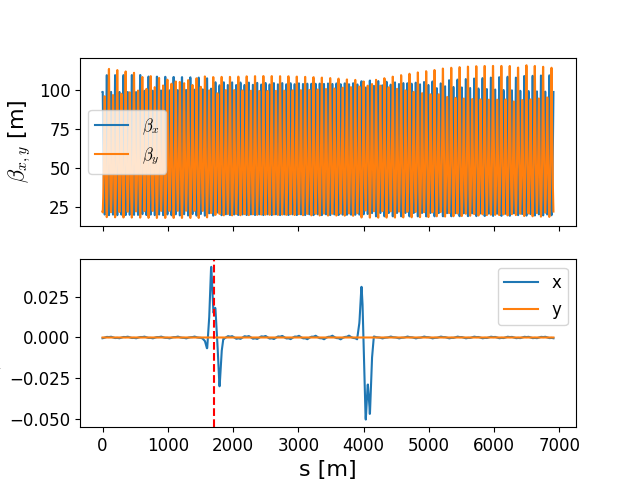

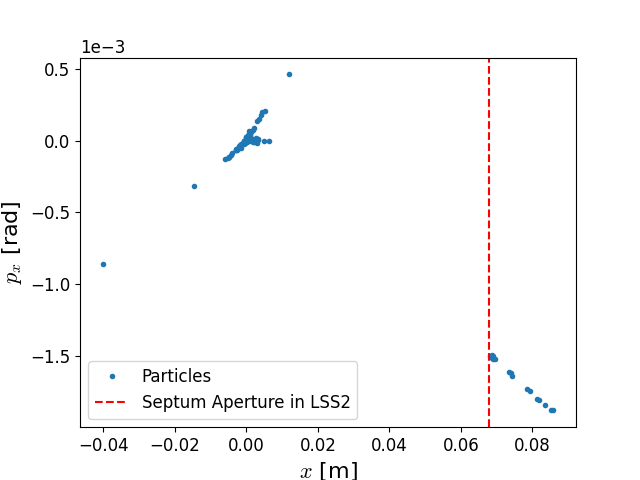

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(twSRX.s, twSRX.betx, label=r'$\beta_x$')  # Add label to the plot
ax1.plot(twSRX.s, twSRX.bety, label=r'$\beta_y$')  # Add label to the plot
ax1.set_ylabel(r"$\beta_{x,y}$ [m]")
ax1.legend()  # Add legend to the plot
ax2.plot(twSRX.s, twSRX.x, label = 'x')
ax2.plot(twSRX.s, twSRX.y, label = 'y')
ax2.axvline(twSRX['s', 'tpst.21760'], color='red', ls='--')
ax2.set_ylabel(r"$x,y$ [m]")
ax2.set_xlabel("s [m]")
ax2.legend()  # Add legend to the plot

plt.figure(2)
plt.plot(particlesSRX.x, particlesSRX.px, ".", label='Particles')
plt.axvline(septum_aperture_size, color="red", ls="--", label='Septum Aperture in LSS2')
plt.xlabel(r"$x$ [m]")
plt.ylabel(r"$p_x$ [rad]")
plt.legend()

### Retreiving x and px at the ZS position

In [16]:
# Get the closed orbit x and px at the ZS position ("ap.up.zs21633")
x_zs = twSRX['x', 'ap.up.zs21633']
px_zs = twSRX['px', 'ap.up.zs21633']

print(f"x at ZS (ap.up.zs21633): {x_zs}")
print(f"px at ZS (ap.up.zs21633): {px_zs}")

x at ZS (ap.up.zs21633): 0.04204418888734364
px at ZS (ap.up.zs21633): -0.0009202496658749898


# Knobs for new optics

In [17]:
from elements import install_septa
#line = xt.Line.from_json("../database/lhc_q22.json")
line = xt.Line.from_json("../database/sps_for_sx.json")

line.vv["extr_bump_knob"] = 1

# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
line.insert_element("TECA.exit", xt.Marker(), at_s = 4020.8939 + TECS.length)

#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']

#line.cycle("TECA.entry", inplace=True)

# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']
tcsm_position = line.get_table()['s', 'tcsm.51932.']

Loading line from dict:   0%|          | 0/4492 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4492 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4495 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4497 [00:00<?, ?it/s]

In [18]:
print_optics_features(line)

26.64945310551331
26.585779397981597
D term / B term = 0.13
sigma_x max = 7.076816518900043 mm
sigma_y max = 1.1465565386252101 mm
D term / B term = 0.13
sigma_x max = 0.007076816518900043 m
sigma_y max = 0.0011465565386252102 m
Phase advance Teca - Tpst: -8.89
Phase advance Teca - Tcsm: 4.61
Phase advance Tpst - Tcsm: 13.50


### Selecting the tunes

In [19]:
#tune = 22.91
tune = 24.39

In [20]:

optTune = match_tunes(line, tune, tune - 0.02)
optChromaticity = match_chromaticity(line, tune, tune - 0.02)

optTune.step(10)
optTune.target_status()
optTune.vary_status()

# CHanging the chromaticity afterwards
optChromaticity.step(10)

optChromaticity.target_status()
optChromaticity.vary_status() 

line.discard_tracker()


                                             
Optimize - start penalty: 31.65         
Matching: model call n. 19               
Optimize - end penalty:  2.77641e-06
Target status:                           
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True  -2.19178e-08         24.39         24.39 'qx', val=24.39, tol=1e-05, weight=10
1  ON    qy     True  -2.76774e-07         24.37         24.37 'qy', val=24.37, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None            0.0136457 None            0.0146593         1e-07             1
1  ON        OK  kqd          None           -0.0136245 None           -0.0146241         1e-07             1
2  ON        OK  qph_setvalue None          2.56056e-11 None                    0        0.0001             1
3  ON        OK  qp

In [21]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')

### Adjusting the lins's apertures

In [22]:
blocking_elements = open_blocking_apertures(line, TECA, deltaP_P)

import elements 
import importlib
importlib.reload(elements)

remove_ZS_apertures(line)
remove_inner_sideLimits_closeTECA(line)

save_df_Limit_elements_features(line)

The line already has an associated tracker
Non-channeled particle not lost during tracking.
The line already has an associated tracker
Channeled particle not lost during tracking.
Blocking elements encountered:
Empty DataFrame
Columns: [Position, Element Name, max_x, min_x]
Index: []


,Position,Element Name,max_x,min_x


### Adjusting the knobs

In [23]:
import optimisers as op
import importlib
importlib.reload(op)

# Define the target x and px values
#x_target = line['tpst.21760_entry.sep'].interaction_process.blade_position 
#px_target = recordNONCH.px[np.where(recordNONCH.s == tpst_position)[0][0]]
px_target = 1e-4
#x_target = 0.0394 * 1.90  # This is the position of the TPST blade times a factor, THIS VALUE IS GOOD FOR THE ORIGINAL POSITION OF THE SEPTUM
x_target = 0.0394 * 1.8

"""
# Adjust the horizontal bump for the extraction
#adjustBumpLSS2 = op.horizontal_bumpLSS2(line, x_target * 0.5, px_target)
adjustBumpLSS2 = op.horizontal_bumpLSS2atZS(line, x_zs , px_zs)

adjustBumpLSS2.log()

adjustBumpLSS2.step(10)
adjustBumpLSS2.target_status()
adjustBumpLSS2.vary_status()
knobs_after_matchLSS2 = adjustBumpLSS2.get_knob_values()
knobs_before_matchLSS2 = adjustBumpLSS2.get_knob_values(iteration=0)

#line.vv["extr_bump_knob"] = 1.0
"""

# Adjust the horizontal bump for the TECA
adjustBumpLSS4 = op.horizontal_bumpLSS4(line)

adjustBumpLSS4.log()

adjustBumpLSS4.step(10)
adjustBumpLSS4.target_status()
adjustBumpLSS4.vary_status()
knobs_after_matchLSS4 = adjustBumpLSS4.get_knob_values()
knobs_before_matchLSS4 = adjustBumpLSS4.get_knob_values(iteration=0)


                                             
Optimize - start penalty: 0.3721        
Matching: model call n. 19               
Optimize - end penalty:  1.71522e-14
                                             
Optimize - start penalty: 1.715e-14      
Matching: model call n. 22               
Optimize - end penalty:  1.71522e-14
Target status:                           
id state tag           tol_met       residue   current_val    target_val description                                 
0  ON    START_x          True             0             0             0 ('x', 'mpsh.41402'), val=0, tol=1e-09, w ...
1  ON    START_px         True             0             0             0 ('px', 'mpsh.41402'), val=0, tol=1e-09,  ...
2  ON    TECA.entry_x     True   3.46945e-17      -0.03374      -0.03374 ('x', 'TECA.entry'), val=-0.03374, tol=1 ...
3  ON    TECA.entry_px    True   1.95156e-18      -0.00157      -0.00157 ('px', 'TECA.entry'), val=-0.00157, tol= ...
4  ON    END_x            True   1.

### Ensuring the closed orbit after the bumps

In [24]:
bump_closed_orbite_LSS2 = ensure_bump_closed(line)

bump_closed_orbite_LSS2.log()

bump_closed_orbite_LSS2.step(10)
bump_closed_orbite_LSS2.target_status()
bump_closed_orbite_LSS2.vary_status()
knobs_after_closingOrbit = bump_closed_orbite_LSS2.get_knob_values()
knobs_after_closingOrbit = bump_closed_orbite_LSS2.get_knob_values(iteration=0)


                                             
Optimize - start penalty: 0.131         
Matching: model call n. 34               
Optimize - end penalty:  1.70226e-10
                                             
Optimize - start penalty: 1.702e-10      
Matching: model call n. 37               
Optimize - end penalty:  1.70226e-10
Target status:                           
id state tag          tol_met       residue   current_val target_val description                                 
0  ON    START_x         True             0             0          0 ('x', 'begi.10010'), val=0, tol=1e-09, w ...
1  ON    START_px        True             0             0          0 ('px', 'begi.10010'), val=0, tol=1e-09,  ...
2  ON    drift_779_x     True   3.23361e-14   3.23361e-14          0 ('x', 'drift_779'), val=0, tol=1e-09, we ...
3  ON    drift_779_px    True    1.6569e-15    1.6569e-15          0 ('px', 'drift_779'), val=0, tol=1e-09, w ...
4  ON    END_x           True  -1.67249e-11  -1.67249e-

In [25]:
print("Extraction Bump values after the matching:")
print(knobs_after_closingOrbit)
print("Extraction Bump values before the matching:")
print(knobs_after_closingOrbit)

Extraction Bump values after the matching:
{'kmpsh21202': -7.6765e-05, 'kmplh21431': 0.00049, 'kmpnh21732': 0.00033309, 'kmplh21995': 0.0002503, 'kmplh22195': -0.00035585, 'kmpsh41402': np.float64(0.000300783195068862), 'kmplh41658': np.float64(-0.0008475909311663074), 'kmplh41994': np.float64(-0.00028943456870158467), 'kmpsh42198': np.float64(-0.0006299165471036526)}
Extraction Bump values before the matching:
{'kmpsh21202': -7.6765e-05, 'kmplh21431': 0.00049, 'kmpnh21732': 0.00033309, 'kmplh21995': 0.0002503, 'kmplh22195': -0.00035585, 'kmpsh41402': np.float64(0.000300783195068862), 'kmplh41658': np.float64(-0.0008475909311663074), 'kmplh41994': np.float64(-0.00028943456870158467), 'kmpsh42198': np.float64(-0.0006299165471036526)}


In [26]:
print("TECA Bump values after the matching:")
print(knobs_after_matchLSS4)
print("TECA Bump values before the matching:")
print(knobs_before_matchLSS4)

TECA Bump values after the matching:
{'kmpsh41402': np.float64(0.000300783195068862), 'kmplh41658': np.float64(-0.0008475909311663074), 'kmplh41994': np.float64(-0.00028943456870158467), 'kmpsh42198': np.float64(-0.0006299165471036526)}
TECA Bump values before the matching:
{'kmpsh41402': 0.0, 'kmplh41658': 0.0, 'kmplh41994': 0.0, 'kmpsh42198': 0.0}


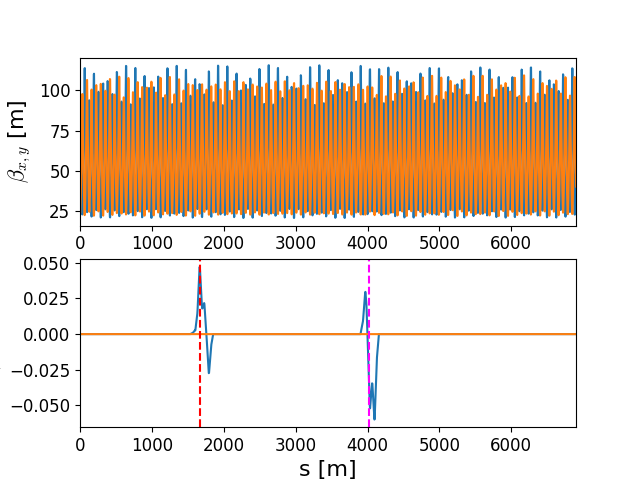

VarsTable: 365 rows, 3 cols
name             value expr
t_turn_s             0 None
version          50902 None
pi             3.14159 None
twopi          6.28319 None
degrad         57.2958 None
raddeg       0.0174533 None
e              2.71828 None
amu0       1.25664e-06 None
emass      0.000510999 None
mumass        0.105658 None
...
kmdv63107             0 None
kmdh63207             0 None
kmdv63307             0 None
kmdh63407             0 None
kmdv63507             0 None
kloe63602             0 None
kmdh63607             0 None
v200                  0 None
freq200           2e+08 None
lag200              180 None

In [27]:
tw = line.twiss(continue_on_closed_orbit_error=True, method = '4d')

plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw.s, tw.betx)
plt.plot(tw.s, tw.bety)
plt.ylabel(r"$\beta_{x,y}$ [m]")
plt.xlim(0,6900)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(tw.s, tw.x)
plt.plot(tw.s, tw.y)
plt.axvline(tw["s", "zs.21633"], color="red", ls="--", label = "ZS entry")
plt.axvline(tw["s", "TECA.entry"], color="magenta", ls="--")
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
plt.show()
plt.xlim(0,6900)


n_part = 200

x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * DPP

particles: xt.Particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

line_df = line.to_pandas()

line.vars.get_table()

# Comparing the knobs

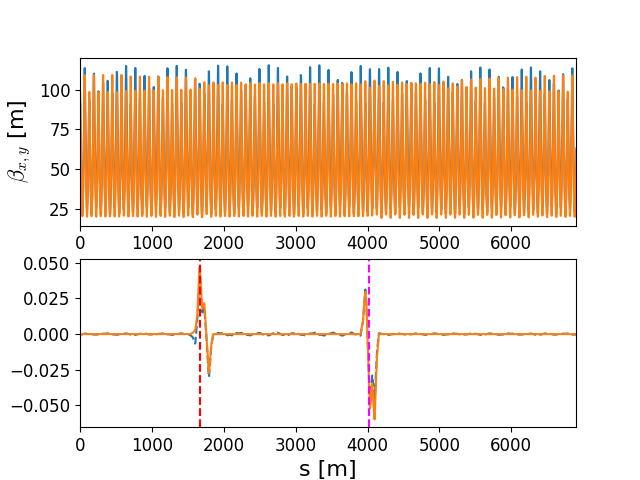

In [28]:
plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw.s, tw.betx)
#plt.plot(tw.s, tw.bety)
plt.plot(twSRX.s, twSRX.betx)
#plt.plot(twSRX.s, twSRX.bety)
plt.ylabel(r"$\beta_{x,y}$ [m]")
plt.xlim(0,6900)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(twSRX.s, twSRX.x, ls="--", label = 'Closed orbit Slow Resonant Extraction')
plt.plot(tw.s, tw.x, label = 'Closed orbit after rematching')
plt.axvline(tw["s", "zs.21633"], color="red", ls="--", label = "ZS entry")
plt.axvline(tw["s", "TECA.entry"], color="magenta", ls="--", label = "TECA")
plt.ylabel(r"$x$ [m]")
plt.xlabel("s [m]")
plt.show()
plt.xlim(0,6900)
plt.legend()
plt.grid()


In [29]:
knobs_after_closingOrbit

{'kmpsh21202': -7.6765e-05,
 'kmplh21431': 0.00049,
 'kmpnh21732': 0.00033309,
 'kmplh21995': 0.0002503,
 'kmplh22195': -0.00035585,
 'kmpsh41402': np.float64(0.000300783195068862),
 'kmplh41658': np.float64(-0.0008475909311663074),
 'kmplh41994': np.float64(-0.00028943456870158467),
 'kmpsh42198': np.float64(-0.0006299165471036526)}

In [30]:
import pandas as pd

# Replace these with the actual names of the four other correctors
corrector_names = [
    'kmpsh21202', 'kmplh21431', 'kmpnh21732', 'kmplh21995', 'kmplh22195',   
    'kmpsh41402', 'kmplh41658', 'kmplh41994', 'kmpsh42198'
]
# Calculate strengths for LSS2 correctors
before_rematching_correctors = [value * lineSRX.vv["extr_bump_knob"] for value in [-1.17064e-4, 4.47223e-4,  3.3309e-4, 2.88705e-4, -3.08688e-4]]
# Add the four values from knobs_after_matchLSS4 to the array
before_rematching_correctors += list(knobs_after_matchLSS4SRX.values())

df_correctors = pd.DataFrame({
    'Corrector Name': corrector_names,
    'Knobs for Slow Resonant Extraction': before_rematching_correctors
})


df_correctors['Knobs After Rematching'] = list(knobs_after_closingOrbit.values())




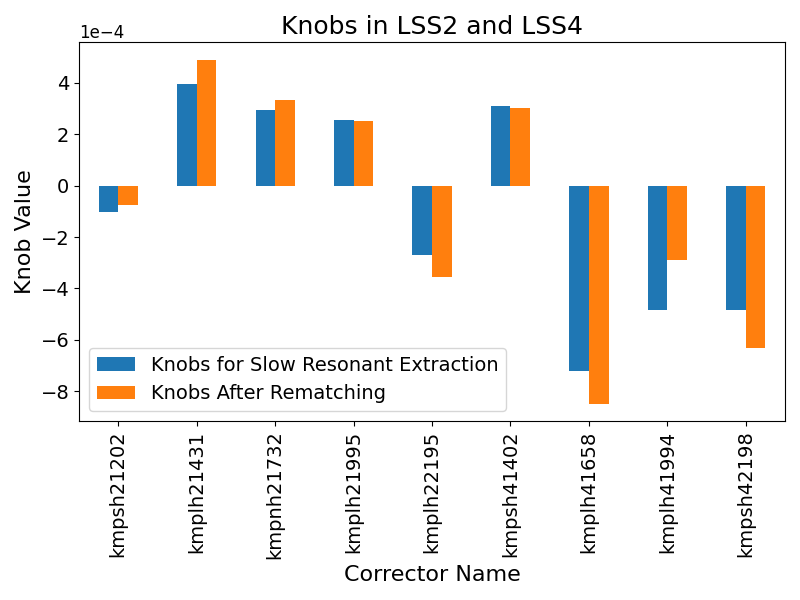

In [35]:
df_correctors.plot(
    x='Corrector Name',
    y=['Knobs for Slow Resonant Extraction', 'Knobs After Rematching'],
    kind='bar',
    title='Knobs in LSS2 and LSS4',
    figsize=(8, 6),
    fontsize=14  # Increase tick label font size
)
plt.title('Knobs in LSS2 and LSS4', fontsize=18)
plt.xlabel('Corrector Name', fontsize=16)
plt.ylabel('Knob Value', fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# Plotting the knobs


In [32]:
# Add a new column to the DataFrame with the values from knobs_after_matchLSS2
#df_strengthsSRXLSS2['Knobs After Match'] = knobs_after_matchLSS2.values() # THIS IS USED WHEN WE USE THE OPTIMISER
#df_strengthsSRXLSS2['Knobs After Match'] = knobs_after_closingOrbit.values() # THIS IS USED WHEN WE USE THE OPTIMISER

"""
 # THIS SNIPPET IS FOR THE LSS2 IN CASE WE USE extraction_bump_knob instead of the optimisation
correctorsLSS2 = ['kmplh21431', 'kmplh21995', 'kmplh22195', 'kmpnh21732', 'kmpsh21202']
strengthsLSS2 = [value * line.vv["extr_bump_knob"] for value in [0.00049, 0.0002503, -0.00035585, 0.00033309, -7.6765e-05]]
df_strengthsSRXLSS2['Knobs After Match'] = strengthsLSS2
 """ 

'\n # THIS SNIPPET IS FOR THE LSS2 IN CASE WE USE extraction_bump_knob instead of the optimisation\ncorrectorsLSS2 = [\'kmplh21431\', \'kmplh21995\', \'kmplh22195\', \'kmpnh21732\', \'kmpsh21202\']\nstrengthsLSS2 = [value * line.vv["extr_bump_knob"] for value in [0.00049, 0.0002503, -0.00035585, 0.00033309, -7.6765e-05]]\ndf_strengthsSRXLSS2[\'Knobs After Match\'] = strengthsLSS2\n '

In [33]:
df_strengthsSRXLSS2

,Corrector Name,Knobs Before Rematching
0,kmplh21431,0.000431
1,kmplh21995,0.000220
2,kmplh22195,-0.000313
3,kmpnh21732,0.000293
4,kmpsh21202,-0.000068


In [34]:
df_strengthsSRXLSS2.plot(x='Corrector Name', y=['Knobs Before Rematching', 'Knobs After Match'], kind='bar', title='Knobs in LSS2', figsize=(8, 6))

KeyError: "['Knobs After Match'] not in index"

<Axes: title={'center': 'Knobs in LSS4'}, xlabel='Corrector Name'>

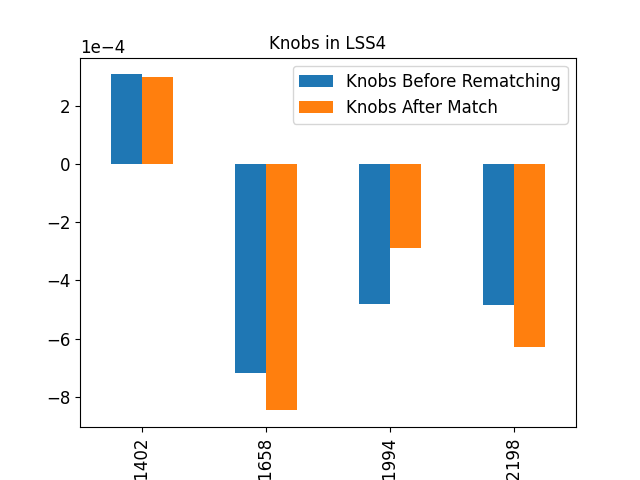

In [ ]:
# Add a new column to the DataFrame with the values from knobs_after_matchLSS4
df_strengthsSRXLSS4['Knobs After Match'] = knobs_after_matchLSS4.values()
df_strengthsSRXLSS4.plot(x='Corrector Name', y=['Knobs Before Rematching', 'Knobs After Match'], kind='bar', title='Knobs in LSS4')